# 01 Disease patterns

Four systemic sclerosis patterns tested against the cleaned layer in `data/processed`, which
`scripts/build.py` writes from the raw tables profiled in `00_first_look.ipynb`. No raw file is
read here.

1. antibodies track subtype
2. skin severity separates the subtypes
3. the lung involvement triangle: Scl-70, anti-centromere, ILD, lung function
4. per-patient FVC slopes over time

Each section states the clinical expectation, then the numbers and the rank or chi-square test
that goes with it. The comorbidity flags `dx_ild`, `dx_gerd` and `dx_pah` are three-state (true,
false, unknown), so every rate built on them is given as the complete-case estimate among the
patients whose field was recorded, together with the lower and upper bounds that the unrecorded
patients allow.

In [1]:
# Imports, project configuration, display settings, the four helpers used in every section, and the cleaned tables
import sys

sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import chi2_contingency, mannwhitneyu, wilcoxon

from ssc_coh.config import PROC_DIR
from ssc_coh.stats import prevalence_summary

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 120)

GREY, RED, BLUE = "#9AA3AD", "#E0483B", "#2E6FE0"


def checks_table(pairs):
    """Turn a list of (check, result) pairs into a two-column table, one row per check."""
    return pd.DataFrame(pairs, columns=["check", "result"])


def rate_under_both_denominators(flag_by_row):
    """One row per entry: the complete-case rate of a three-state comorbidity flag, then the two
    bounds that read every unrecorded field first as a negative and then as a positive."""
    summaries = [prevalence_summary(flag_values) for flag_values in flag_by_row.values()]
    return pd.DataFrame([{"n_field_recorded": summary.n_recorded,
                          "pct_complete_case": round(summary.complete_case_rate * 100, 1),
                          "n_all_patients": summary.n_all,
                          "pct_lower_bound": round(summary.lower_bound * 100, 1),
                          "pct_upper_bound": round(summary.upper_bound * 100, 1)}
                         for summary in summaries],
                        index=list(flag_by_row))


def chi_square_check(label, first_column, second_column):
    """One (check, result) pair: chi-square test of independence between two categorical columns."""
    contingency_table = pd.crosstab(first_column, second_column)
    chi_square, p_value, _, _ = chi2_contingency(contingency_table)
    return label, f"chi-square {chi_square:.1f}, p = {p_value:.2g}, n = {int(contingency_table.to_numpy().sum())}"


def mann_whitney_check(label, first_values, second_values):
    """One (check, result) pair: Mann-Whitney rank test between two samples, missing values dropped."""
    first_present, second_present = first_values.dropna(), second_values.dropna()
    statistic, p_value = mannwhitneyu(first_present, second_present)
    return label, f"U = {statistic:.0f}, p = {p_value:.2g}, n = {len(first_present)} and {len(second_present)}"


features = pd.read_parquet(PROC_DIR / "features.parquet")
mrss = pd.read_parquet(PROC_DIR / "mrss.parquet")
pft = pd.read_parquet(PROC_DIR / "pft.parquet")
antibodies = pd.read_parquet(PROC_DIR / "antibodies.parquet")
issues = pd.read_parquet(PROC_DIR / "issues.parquet")
processed_tables = {"features": features, "mrss": mrss, "pft": pft, "antibodies": antibodies, "issues": issues}
pd.DataFrame({"rows": {name: len(table) for name, table in processed_tables.items()},
              "columns": {name: table.shape[1] for name, table in processed_tables.items()},
              "first columns": {name: ", ".join(table.columns[:4]) for name, table in processed_tables.items()}})

,rows,columns,first columns
features,1498,74,"subject_id, first name, last name, birth_date"
mrss,3110,5,"subject_id, date, rater, score"
pft,5060,5,"subject_id, date, measure, value"
antibodies,3509,5,"subject_id, date, test_short, value"
issues,49,5,"table, issue, decision, n_affected"


## Cohort snapshot

Composition of the cleaned cohort before any pattern is tested, and the state of the three
comorbidity flags that the later sections depend on.

In [2]:
# Sex and subtype counts, the cohort numbers, and how many patients carry each kind of measurement
cohort_composition = pd.concat({column: features[column].value_counts(dropna=False)
                                for column in ["gender", "ssc_subtype"]})
cohort_composition = cohort_composition.rename("patients").rename_axis(["column", "value"]).to_frame()
cohort_composition["share_pct"] = (cohort_composition["patients"] / len(features) * 100).round(1)
display(cohort_composition)
display(checks_table([
    ("patients", len(features)),
    ("features per patient", features.shape[1]),
    ("age in years: median, range", f"{features['age_years'].median():.0f}, "
                                    f"{features['age_years'].min():.0f} to {features['age_years'].max():.0f}"),
    ("limited to diffuse ratio", f"{features['ssc_subtype'].eq('lcSSc').sum() / features['ssc_subtype'].eq('dcSSc').sum():.2f} to 1"),
    ("comorbidity field recorded, not recorded", f"{int(features['dx_ild'].notna().sum())}, {int(features['dx_ild'].isna().sum())}"),
    ("entries in the issue log", len(issues)),
]))
pd.DataFrame({"patients": {
    "latest mRSS": int(features["mrss_latest"].notna().sum()),
    "latest FVC": int(features["fvc"].notna().sum()),
    "latest DLCO": int(features["dlco_sb"].notna().sum()),
    "anti-centromere positive or negative": int(features["ab_aca"].isin(["positive", "negative"]).sum()),
    "Scl-70 positive or negative": int(features["ab_scl70"].isin(["positive", "negative"]).sum()),
    "RNA Pol III positive or negative": int(features["ab_rna_pol3"].isin(["positive", "negative"]).sum()),
    "at least three FVC tests": int(features["fvc_slope_pct_yr"].notna().sum()),
}}).rename_axis("measurement")

patients  share_pct
column      value                      
gender      Female      1235       82.4
            Male         263       17.6
ssc_subtype lcSSc        900       60.1
            dcSSc        598       39.9

,check,result
0,patients,1498
1,features per patient,74
2,"age in years: median, range","59, 36 to 82"
3,limited to diffuse ratio,1.51 to 1
4,"comorbidity field recorded, not recorded","943, 555"
5,entries in the issue log,49


,patients
measurement,
latest mRSS,821
latest FVC,1170
latest DLCO,559
anti-centromere positive or negative,914
Scl-70 positive or negative,993
RNA Pol III positive or negative,820
at least three FVC tests,108


In [3]:
# The three comorbidity flags under both readings of an unrecorded other_dx field
comorbidity_rate_by_flag = rate_under_both_denominators({"ILD": features["dx_ild"],
                                                         "GERD": features["dx_gerd"],
                                                         "PAH": features["dx_pah"]})
comorbidity_rate_by_flag

,n_field_recorded,pct_complete_case,n_all_patients,pct_lower_bound,pct_upper_bound
ILD,943,67.1,1498,42.3,79.3
GERD,943,45.5,1498,28.6,65.7
PAH,943,12.4,1498,7.8,44.9


- 1,498 patients with 74 features each, and 49 entries in the issue log written by the cleaning
  layer.
- 82.4% female (1,235 of 1,498), which matches SSc epidemiology at about 4 to 5 women per man.
- 900 limited and 598 diffuse, 1.51 to 1; age median 59, range 36 to 82.
- Coverage is uneven: 821 of the 1,498 patients have a skin score, 1,170 a latest FVC,
  559 a latest DLCO, and 108 have the three or more FVC tests a slope needs.
- `other_dx` was filled in for 943 patients and left empty for 555, so every comorbidity rate is
  reported as a complete-case estimate with two bounds: ILD 67.1% of the 943 recorded, bounded by
  42.3% and 79.3% of all 1,498; GERD 45.5%, bounded by 28.6% and 65.7%; PAH 12.4%, bounded by
  7.8% and 44.9%. The bounds read every empty field first as no comorbidity and then as a
  comorbidity, so they measure how far the missing field alone can move each rate. Nothing here
  says where in that range the recorded rate would land if the field had been filled in.

## Pattern 1: antibodies track subtype

Anti-centromere marks limited disease; Scl-70 and RNA Pol III mark diffuse disease. Each patient
contributes the latest result per test; patients whose latest result is borderline or indeterminate
stay in the cleaned table and out of these rates.

,patients_tested,pct_positive_lcSSc,pct_positive_dcSSc
antibody,,,
anti-centromere,914,47.1,5.0
Scl-70,993,36.9,52.3
RNA Pol III,820,8.4,13.1


,check,result
0,anti-centromere against subtype,"chi-square 174.2, p = 8.8e-40, n = 914"
1,Scl-70 against subtype,"chi-square 22.7, p = 1.9e-06, n = 993"
2,RNA Pol III against subtype,"chi-square 4.3, p = 0.039, n = 820"
3,antibody results that are borderline or indeterminate,78
4,patients whose result flips between positive and negative (result_flip_flag),15


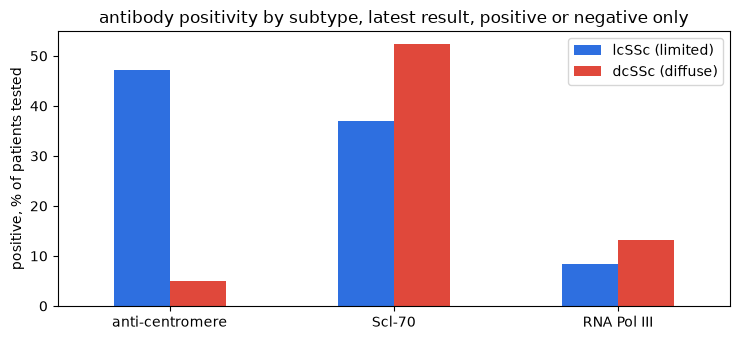

In [4]:
# Positivity rate of each antibody within each subtype, the chi-square test per antibody, and the same rates as bars
antibody_labels = {"ab_aca": "anti-centromere", "ab_scl70": "Scl-70", "ab_rna_pol3": "RNA Pol III"}
positivity_rows, antibody_checks = [], []
for antibody_column, antibody_label in antibody_labels.items():
    definite_results = features[features[antibody_column].isin(["positive", "negative"])]
    positivity_pct = pd.crosstab(definite_results[antibody_column], definite_results["ssc_subtype"],
                                 normalize="columns").loc["positive"] * 100
    positivity_rows.append({"antibody": antibody_label,
                            "patients_tested": len(definite_results),
                            "pct_positive_lcSSc": round(positivity_pct["lcSSc"], 1),
                            "pct_positive_dcSSc": round(positivity_pct["dcSSc"], 1)})
    antibody_checks.append(chi_square_check(f"{antibody_label} against subtype",
                                            definite_results[antibody_column], definite_results["ssc_subtype"]))
antibody_positivity_by_subtype = pd.DataFrame(positivity_rows).set_index("antibody")
antibody_checks.append(("antibody results that are borderline or indeterminate",
                        int(antibodies["value"].isin(["borderline", "indeterminate"]).sum())))
antibody_checks.append(("patients whose result flips between positive and negative (result_flip_flag)",
                        int(antibodies.loc[antibodies["result_flip_flag"], "subject_id"].nunique())))
display(antibody_positivity_by_subtype)
display(checks_table(antibody_checks))
ax = antibody_positivity_by_subtype[["pct_positive_lcSSc", "pct_positive_dcSSc"]].plot.bar(
    rot=0, figsize=(7.5, 3.5), color=[BLUE, RED])
ax.set_title("antibody positivity by subtype, latest result, positive or negative only")
ax.set_ylabel("positive, % of patients tested")
ax.set_xlabel("")
ax.legend(["lcSSc (limited)", "dcSSc (diffuse)"])
plt.tight_layout()

- Anti-centromere gives the sharpest split: positive in 47.1% of limited patients against 5.0% of
  diffuse, a 9-fold gap across 914 tested patients.
- Scl-70 leans the other way, 52.3% diffuse against 36.9% limited. RNA Pol III leans the same way but
  weakly, 13.1% against 8.4%, and clears the 0.05 line without much room (p = 0.039).
- All three directions are the ones the clinical literature reports, which is consistent with the
  antibody table being joined to the right patients and its result labels being intact. The
  linkage itself is checked by id sets, referential integrity, duplicate keys and row counts, not
  by this.
- 78 results are borderline or indeterminate and sit outside these rates; 15 patients switch
  between positive and negative on repeat testing and carry `result_flip_flag`.

## Pattern 2: skin severity separates the subtypes

mRSS is the modified Rodnan skin score: 17 body sites pinched and scored 0 to 3, added up to 0 to
51, higher meaning thicker skin. Skin extent is part of how the limited and diffuse subtypes are
defined, so this is the one pattern that has to hold if the subtype labels mean anything.

,patients_scored,latest_q25,latest_median,latest_q75,mean_across_visits_median
ssc_subtype,,,,,
dcSSc,327,21.0,24.0,28.0,23.4
lcSSc,494,5.0,8.0,12.0,8.0


,check,result
0,"skin score visits, patients scored","3110, 821"
1,"latest mRSS, lcSSc against dcSSc","U = 1688, p = 4.3e-125, n = 494 and 327"
2,"mean mRSS across visits, lcSSc against dcSSc","U = 482, p = 9.7e-129, n = 494 and 327"


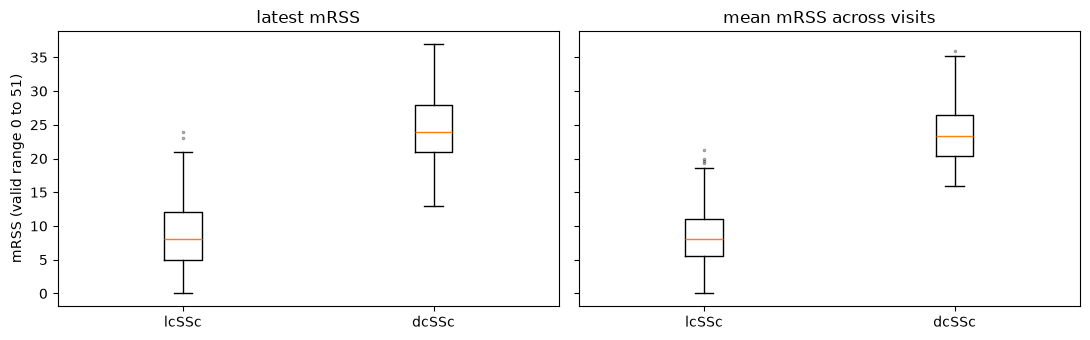

In [5]:
# Latest and mean mRSS per subtype with quartiles, the rank test on the latest score, and the two distributions as box plots
mrss_latest_by_subtype = features.groupby("ssc_subtype")["mrss_latest"]
mrss_by_subtype = pd.DataFrame({
    "patients_scored": mrss_latest_by_subtype.count(),
    "latest_q25": mrss_latest_by_subtype.quantile(0.25),
    "latest_median": mrss_latest_by_subtype.median(),
    "latest_q75": mrss_latest_by_subtype.quantile(0.75),
    "mean_across_visits_median": features.groupby("ssc_subtype")["mrss_mean"].median(),
}).round(1)
display(mrss_by_subtype)
display(checks_table([
    ("skin score visits, patients scored", f"{len(mrss)}, {mrss['subject_id'].nunique()}"),
    mann_whitney_check("latest mRSS, lcSSc against dcSSc",
                       features.loc[features["ssc_subtype"] == "lcSSc", "mrss_latest"],
                       features.loc[features["ssc_subtype"] == "dcSSc", "mrss_latest"]),
    mann_whitney_check("mean mRSS across visits, lcSSc against dcSSc",
                       features.loc[features["ssc_subtype"] == "lcSSc", "mrss_mean"],
                       features.loc[features["ssc_subtype"] == "dcSSc", "mrss_mean"]),
]))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
for ax, mrss_column, title in [(axes[0], "mrss_latest", "latest mRSS"),
                               (axes[1], "mrss_mean", "mean mRSS across visits")]:
    scores_by_subtype = [features.loc[features["ssc_subtype"] == subtype, mrss_column].dropna()
                         for subtype in ["lcSSc", "dcSSc"]]
    ax.boxplot(scores_by_subtype, tick_labels=["lcSSc", "dcSSc"],
               flierprops=dict(marker=".", markersize=3, alpha=0.4))
    ax.set_title(title)
axes[0].set_ylabel("mRSS (valid range 0 to 51)")
plt.tight_layout()

- Diffuse patients score a median 24 against 8 for limited, quartiles 21 to 28 against 5 to 12, so
  the two middle halves do not overlap at all.
- The mean across visits gives the same separation (23.4 against 8.0), so this is not one unusual
  visit per patient.
- 821 of the 1,498 patients have a skin score, across 3,110 visits. The rest of the cohort says
  nothing about skin, which is a selection effect for anything built on mRSS alone.

## Pattern 3: the lung involvement triangle

Scl-70 should raise the risk of interstitial lung disease, anti-centromere should lower it, and
diffuse patients should sit lower on lung function than limited patients. ILD comes from the
free-text `other_dx` field, so its rate is shown as a complete-case estimate with the lower and
upper bounds the unrecorded patients allow.

FEV1 is left out of this section and of every other one. In this dataset it tracks FVC and adds no
usable variation, so including it would only repeat FVC in a second column; the visits where FEV1
came out above FVC are marked by `fev1_gt_fvc_flag` in `pft.parquet`.

,n_field_recorded,pct_complete_case,n_all_patients,pct_lower_bound,pct_upper_bound
Scl-70 positive,331,84.0,430,64.7,87.7
Scl-70 negative,318,57.2,563,32.3,75.8
anti-centromere positive,140,37.1,287,18.1,69.3
anti-centromere negative,427,74.0,627,50.4,82.3
dcSSc (diffuse),439,86.1,598,63.2,89.8
lcSSc (limited),504,50.6,900,28.3,72.3


,check,result
0,"Scl-70 against ILD, patients with the field recorded","chi-square 55.0, p = 1.2e-13, n = 649"
1,"Scl-70 against ILD, all patients, empty read as no ILD","chi-square 101.2, p = 8.5e-24, n = 993"
2,"anti-centromere against ILD, patients with the field recorded","chi-square 61.3, p = 4.9e-15, n = 567"
3,"anti-centromere against ILD, all patients, empty read as no ILD","chi-square 84.0, p = 5.1e-20, n = 914"


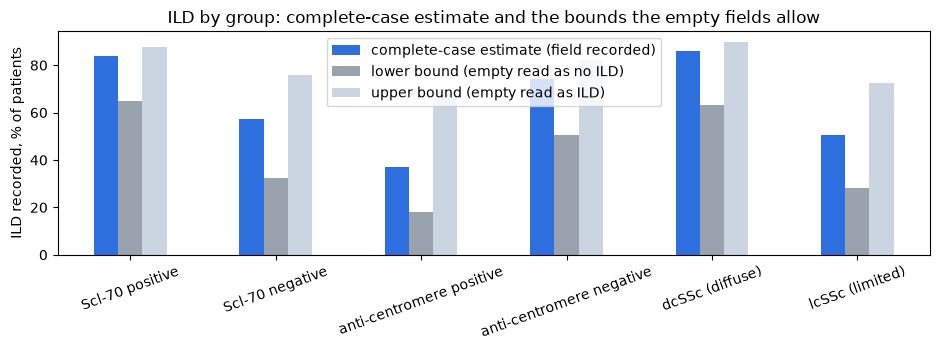

In [6]:
# ILD rate in each antibody and subtype group under both readings of an unrecorded field, the chi-square tests under each, and the same rates as bars
ild_group_masks = {
    "Scl-70 positive": features["ab_scl70"].eq("positive"),
    "Scl-70 negative": features["ab_scl70"].eq("negative"),
    "anti-centromere positive": features["ab_aca"].eq("positive"),
    "anti-centromere negative": features["ab_aca"].eq("negative"),
    "dcSSc (diffuse)": features["ssc_subtype"].eq("dcSSc"),
    "lcSSc (limited)": features["ssc_subtype"].eq("lcSSc"),
}
ild_rate_by_group = rate_under_both_denominators({group_name: features.loc[group_mask, "dx_ild"]
                                                  for group_name, group_mask in ild_group_masks.items()})
scl70_definite = features[features["ab_scl70"].isin(["positive", "negative"])]
aca_definite = features[features["ab_aca"].isin(["positive", "negative"])]
scl70_field_recorded = scl70_definite[scl70_definite["dx_ild"].notna()]
aca_field_recorded = aca_definite[aca_definite["dx_ild"].notna()]
display(ild_rate_by_group)
display(checks_table([
    chi_square_check("Scl-70 against ILD, patients with the field recorded",
                     scl70_field_recorded["ab_scl70"], scl70_field_recorded["dx_ild"]),
    chi_square_check("Scl-70 against ILD, all patients, empty read as no ILD",
                     scl70_definite["ab_scl70"], scl70_definite["dx_ild"].fillna(False)),
    chi_square_check("anti-centromere against ILD, patients with the field recorded",
                     aca_field_recorded["ab_aca"], aca_field_recorded["dx_ild"]),
    chi_square_check("anti-centromere against ILD, all patients, empty read as no ILD",
                     aca_definite["ab_aca"], aca_definite["dx_ild"].fillna(False)),
]))
ax = (ild_rate_by_group[["pct_complete_case", "pct_lower_bound", "pct_upper_bound"]]
      .plot.bar(rot=20, figsize=(9.5, 3.6), color=[BLUE, GREY, "#CBD5E1"]))
ax.set_title("ILD by group: complete-case estimate and the bounds the empty fields allow")
ax.set_ylabel("ILD recorded, % of patients")
ax.set_xlabel("")
ax.legend(["complete-case estimate (field recorded)", "lower bound (empty read as no ILD)",
           "upper bound (empty read as ILD)"])
plt.tight_layout()

,patients_with_fvc,fvc_median,patients_with_dlco,dlco_median
ssc_subtype,,,,
dcSSc,475,78.5,216,74.0
lcSSc,695,88.0,343,77.9


,check,result
0,"latest FVC, lcSSc against dcSSc","U = 214814, p = 1.9e-18, n = 695 and 475"
1,"latest DLCO, lcSSc against dcSSc","U = 46249, p = 7.4e-07, n = 343 and 216"
2,"latest FVC median, limited minus diffuse (% predicted points)",9.5
3,"latest DLCO median, limited minus diffuse (% predicted points)",3.9
4,PFT visits with FEV1 above FVC (fev1_gt_fvc_flag),904


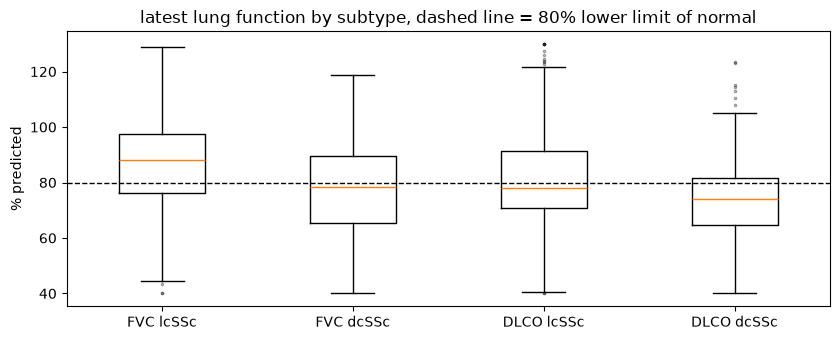

In [7]:
# Latest FVC and DLCO per subtype, the rank tests, the FEV1 flag count, and the four distributions against the 80% lower limit of normal
lung_function_by_subtype = pd.DataFrame({
    "patients_with_fvc": features.groupby("ssc_subtype")["fvc"].count(),
    "fvc_median": features.groupby("ssc_subtype")["fvc"].median(),
    "patients_with_dlco": features.groupby("ssc_subtype")["dlco_sb"].count(),
    "dlco_median": features.groupby("ssc_subtype")["dlco_sb"].median(),
}).round(1)
display(lung_function_by_subtype)
display(checks_table([
    mann_whitney_check("latest FVC, lcSSc against dcSSc",
                       features.loc[features["ssc_subtype"] == "lcSSc", "fvc"],
                       features.loc[features["ssc_subtype"] == "dcSSc", "fvc"]),
    mann_whitney_check("latest DLCO, lcSSc against dcSSc",
                       features.loc[features["ssc_subtype"] == "lcSSc", "dlco_sb"],
                       features.loc[features["ssc_subtype"] == "dcSSc", "dlco_sb"]),
    ("latest FVC median, limited minus diffuse (% predicted points)",
     round(lung_function_by_subtype.loc["lcSSc", "fvc_median"] - lung_function_by_subtype.loc["dcSSc", "fvc_median"], 1)),
    ("latest DLCO median, limited minus diffuse (% predicted points)",
     round(lung_function_by_subtype.loc["lcSSc", "dlco_median"] - lung_function_by_subtype.loc["dcSSc", "dlco_median"], 1)),
    ("PFT visits with FEV1 above FVC (fev1_gt_fvc_flag)",
     int(pft.loc[pft["fev1_gt_fvc_flag"], ["subject_id", "date"]].drop_duplicates().shape[0])),
]))
fig, ax = plt.subplots(figsize=(8.5, 3.5))
lung_values_by_group = [features.loc[features["ssc_subtype"] == subtype, lung_column].dropna()
                        for lung_column in ["fvc", "dlco_sb"] for subtype in ["lcSSc", "dcSSc"]]
ax.boxplot(lung_values_by_group, tick_labels=["FVC lcSSc", "FVC dcSSc", "DLCO lcSSc", "DLCO dcSSc"],
           flierprops=dict(marker=".", markersize=3, alpha=0.4))
ax.axhline(80, color="black", ls="--", lw=1)
ax.set_title("latest lung function by subtype, dashed line = 80% lower limit of normal")
ax.set_ylabel("% predicted")
plt.tight_layout()

- Recorded ILD is more common with Scl-70 positivity, less common with anti-centromere
  positivity, and more common in diffuse disease. Among patients whose comorbidity field was
  recorded it is noted for 84.0% of Scl-70 positive against 57.2% of Scl-70 negative patients, for
  37.1% of anti-centromere positive against 74.0% of anti-centromere negative, and for 86.1% of
  diffuse against 50.6% of limited.
- The bounds are wide but the ordering survives both of them. Reading every empty field as no ILD
  gives 64.7% against 32.3% for Scl-70, 18.1% against 50.4% for anti-centromere, 63.2% against
  28.3% by subtype; reading every empty field as ILD gives 87.7% against 75.8%, 69.3% against
  82.3%, and 89.8% against 72.3%. The chi-square is decisive under either denominator that can be
  tested, so the association does not depend on which reading is chosen.
- Lung function is lower in diffuse disease: latest FVC median 78.5 against 88.0, a gap of 9.5
  points, and latest DLCO 74.0 against 77.9, a gap of 3.9. Both diffuse medians sit below the 80%
  lower limit of normal; among limited patients FVC is above it and DLCO just below.
- 904 PFT visits carry `fev1_gt_fvc_flag`. They are kept in the cleaned table and used nowhere in
  this notebook.

## Pattern 4: per-patient FVC slopes center on zero

Annual FVC decline is the standard endpoint in SSc trials, so it is the first longitudinal signal
worth looking for. Each slope is a least-squares fit of FVC on time for one patient, computed only
where that patient has at least three distinct measurement dates. Repeat tests on one date add no
time point, so the rule counts dates rather than rows. The cell after the slopes reports how much
follow-up those qualifying patients actually cover.

,count,mean,25%,50%,75%
ssc_subtype,,,,,
dcSSc,44.0,0.25,-1.44,0.8,1.63
lcSSc,64.0,0.12,-1.40,0.6,1.81


,check,result
0,patients with at least three FVC tests,108
1,"slope median, mean over the whole cohort (% predicted per year)","0.60, 0.18"
2,patients whose slope falls rather than rises,47 (43.5%)
3,"FVC slope, lcSSc against dcSSc","U = 1418, p = 0.96, n = 64 and 44"
4,FVC slope against zero (Wilcoxon signed rank),"W = 2614, p = 0.31, n = 108"


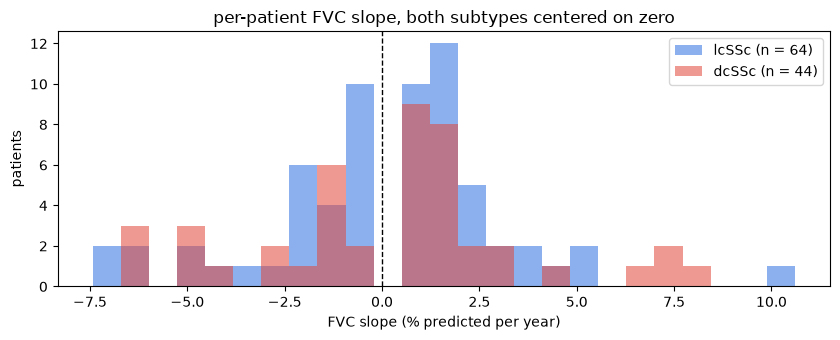

In [8]:
# Per-patient FVC slope by subtype, the two rank tests, and the two distributions on shared bins
fvc_slopes = features.dropna(subset=["fvc_slope_pct_yr"])
fvc_slope_by_subtype = (fvc_slopes.groupby("ssc_subtype")["fvc_slope_pct_yr"]
                                  .describe()[["count", "mean", "25%", "50%", "75%"]].round(2))
slope_statistic, slope_p_value = wilcoxon(fvc_slopes["fvc_slope_pct_yr"])
display(fvc_slope_by_subtype)
display(checks_table([
    ("patients with at least three FVC tests", len(fvc_slopes)),
    ("slope median, mean over the whole cohort (% predicted per year)",
     f"{fvc_slopes['fvc_slope_pct_yr'].median():.2f}, {fvc_slopes['fvc_slope_pct_yr'].mean():.2f}"),
    ("patients whose slope falls rather than rises",
     f"{int((fvc_slopes['fvc_slope_pct_yr'] < 0).sum())} ({(fvc_slopes['fvc_slope_pct_yr'] < 0).mean():.1%})"),
    mann_whitney_check("FVC slope, lcSSc against dcSSc",
                       fvc_slopes.loc[fvc_slopes["ssc_subtype"] == "lcSSc", "fvc_slope_pct_yr"],
                       fvc_slopes.loc[fvc_slopes["ssc_subtype"] == "dcSSc", "fvc_slope_pct_yr"]),
    ("FVC slope against zero (Wilcoxon signed rank)",
     f"W = {slope_statistic:.0f}, p = {slope_p_value:.2g}, n = {len(fvc_slopes)}"),
]))
fig, ax = plt.subplots(figsize=(8.5, 3.5))
slope_bins = np.linspace(fvc_slopes["fvc_slope_pct_yr"].min(), fvc_slopes["fvc_slope_pct_yr"].max(), 26)
for subtype, fill_color in [("lcSSc", BLUE), ("dcSSc", RED)]:
    slopes_in_subtype = fvc_slopes.loc[fvc_slopes["ssc_subtype"] == subtype, "fvc_slope_pct_yr"]
    ax.hist(slopes_in_subtype, bins=slope_bins, alpha=0.55, color=fill_color,
            label=f"{subtype} (n = {len(slopes_in_subtype)})")
ax.axvline(0, color="black", ls="--", lw=1)
ax.set_title("per-patient FVC slope, both subtypes centered on zero")
ax.set_xlabel("FVC slope (% predicted per year)")
ax.set_ylabel("patients")
ax.legend()
plt.tight_layout()

In [9]:
# How much follow-up the qualifying patients cover: tests per patient and the span between first and last test
eligible_patient_ids = fvc_slopes["subject_id"]
fvc_dates_by_patient = (pft[pft["measure"].eq("FVC") & pft["subject_id"].isin(eligible_patient_ids)]
                        .groupby("subject_id")["date"])
tests_per_patient = fvc_dates_by_patient.nunique()
follow_up_years = (fvc_dates_by_patient.max() - fvc_dates_by_patient.min()).dt.days / 365.25
display(checks_table([
    ("patients qualifying for a slope", len(follow_up_years)),
    ("distinct FVC measurement dates per patient (median, max)",
     f"{tests_per_patient.median():.0f}, {tests_per_patient.max():.0f}"),
    ("span from first to last test in years (median, min, max)",
     f"{follow_up_years.median():.2f}, {follow_up_years.min():.2f}, {follow_up_years.max():.2f}"),
    ("patients whose span is under one year",
     f"{int((follow_up_years < 1).sum())} of {len(follow_up_years)}"),
]))

,check,result
0,patients qualifying for a slope,108
1,"distinct FVC measurement dates per patient (median, max)","3, 4"
2,"span from first to last test in years (median, min, max)","1.00, 0.83, 3.66"
3,patients whose span is under one year,72 of 108


- No cohort-level decline was detected among the patients who qualify for this exploratory slope
  analysis. 108 patients have at least three distinct FVC measurement dates; their slopes center
  just above zero, median 0.60 and mean 0.18% predicted per year, and 47 of them (43.5%) fall
  rather than rise.
- The two subtypes are indistinguishable (median 0.6 limited against 0.8 diffuse, p = 0.96) and
  the whole set does not differ from zero (p = 0.31).
- The qualifying series are short: median span 1.00 year, 72 of 108 under a year, and a median of
  3 measurement dates per patient. That is a weak base for an annual rate of change, so the
  finding is about these 108 short series and not about the disease or the rest of the cohort.
- Reported as it came out; reading this spread as decline would be as wrong as cleaning a real
  signal away.

## Takeaways

- The cohort has the shape SSc epidemiology predicts before any modeling: 82.4% female, 900
  limited against 598 diffuse, ages 36 to 82.
- Antibodies track subtype in the directions the literature reports. Anti-centromere is 47.1%
  positive in limited disease against 5.0% in diffuse; Scl-70 and RNA Pol III lean diffuse.
- Skin severity separates the subtypes almost completely, median mRSS 24 diffuse against 8
  limited, and the mean across visits agrees.
- Recorded ILD moves with both antibody edges and with lung function: 84.0% against 57.2% by
  Scl-70 status among patients with the field recorded, latest FVC median 78.5 diffuse against
  88.0 limited.
- Every ILD, GERD and PAH rate carries a complete-case estimate and two bounds, because `other_dx`
  was left empty for 555 patients. The bounds show how far the empty fields alone can move a rate,
  and no analysis here picks a point inside them.
- No cohort-level FVC decline was detected among the 108 patients who qualify for the exploratory
  slope analysis: their slopes center at 0.60% predicted per year, not different between subtypes
  and not different from zero, over a median span of 1.00 year with 72 of 108 under a year.